# 05 — Compare runs

**Phase 4.** Loads `experiments/registry.csv` + any set of `metrics.jsonl` files and renders
loss-vs-tokens, loss-vs-wall-clock, tokens/sec, and memory. `plot_runs([...run_ids])` is the
reusable entry point every phase-5 ablation study will call. The last section is a "how to
read a loss curve" walkthrough grounded in this session's actual `p4_smoke` numbers.

Run this notebook again once the overnight lr-sweep + baseline pipeline
(`scripts/orchestrate_p4_lr_sweep_and_baseline.py`, launched 2026-07-11 22:42) has finished --
the lr-sweep and baseline cells below are written to skip gracefully if those runs don't exist
yet, and pick them up automatically once they do.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "../src")

ROOT = Path("..").resolve()
EXPERIMENTS_DIR = ROOT / "experiments"
REGISTRY_PATH = EXPERIMENTS_DIR / "registry.csv"

## 1. The registry

One row per run (append-only, `docs/EXPERIMENTS.md` schema). Phase 4's rows so far -- a run's
`verdict` column is a provisional placeholder ("review and fill in notes.md") until a session
reads the run's `notes.md` and writes the real one-sentence verdict, per the ablation protocol.

In [2]:
registry = pd.read_csv(REGISTRY_PATH)
registry[registry["phase"] == 4]

,run_id,date,phase,tier,params_M,baseline_run,variable_changed,tokens_trained_M,final_val_loss,final_ppl,wall_hours,wandb_url,verdict
5,20260711_p4_cpu-canary,2026-07-11,4,S,9.71,-,-,0.04,8.6874,5927.93,0.051,-,completed at step 10/10 -- review and fill in ...
6,20260711_p4_s-smoke,2026-07-11,4,S,9.71,-,-,9.83,5.2427,189.18,0.34,-,completed at step 150/150 -- review and fill i...
7,20260711_p4_resume-test,2026-07-11,4,S,9.71,-,-,0.0,9.4054,12154.42,0.008,-,interrupted at step 1/10 -- review and fill in...
8,20260711_p4_resume-test,2026-07-11,4,S,9.71,-,-,0.04,8.6874,5927.93,0.048,-,completed at step 10/10 -- review and fill in ...
9,20260711_p4_s-lr-sweep-lo,2026-07-11,4,S,9.71,20260711_p4_s-baseline,lr=3e-4 (0.3x baseline),19.66,5.2486,190.3,0.497,-,Worst of the 3 at every checkpoint (not unstab...
10,20260711_p4_s-lr-sweep-mid,2026-07-11,4,S,9.71,20260711_p4_s-baseline,"lr=1e-3 (1x baseline, sweep control)",19.66,4.7293,113.22,0.489,-,WINNER -- strictly ahead of lo/hi at every log...
11,20260711_p4_s-lr-sweep-hi,2026-07-12,4,S,9.71,20260711_p4_s-baseline,lr=3e-3 (3x baseline),19.66,4.8426,126.8,0.49,-,Worse than mid but no divergence (grad_clip=1....
12,20260711_p4_s-baseline,2026-07-12,4,S,9.71,-,-,98.3,3.5037,33.24,2.425,-,THE S-tier reference run. val_loss 9.55->3.50 ...


## 2. Loading metrics + `plot_runs`

`metrics.jsonl` is one JSON object per logged step (`docs/EXPERIMENTS.md` schema); `val_loss`
only appears on eval steps, so it's a sparser column than `train_loss`.

In [3]:
def load_metrics(run_id: str) -> pd.DataFrame:
    path = EXPERIMENTS_DIR / run_id / "metrics.jsonl"
    records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    return pd.DataFrame(records)


def plot_runs(run_ids: list[str], labels: dict[str, str] | None = None):
    """loss-vs-tokens (solid=train, dashed=val), loss-vs-wallclock, tokens/sec, memory --
    the standard 4-panel comparison every phase-5 ablation study will reuse. Runs that don't
    have a metrics.jsonl yet (e.g. still running, or not launched) are skipped with a note
    rather than raising, so this cell is safe to re-run mid-pipeline."""
    labels = labels or {}
    available = [r for r in run_ids if (EXPERIMENTS_DIR / r / "metrics.jsonl").exists()]
    missing = [r for r in run_ids if r not in available]
    if missing:
        print(f"skipping (no metrics.jsonl yet): {missing}")
    if not available:
        print("nothing to plot")
        return None

    dfs = {r: load_metrics(r) for r in available}
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for run_id, df in dfs.items():
        label = labels.get(run_id, run_id)
        line, = axes[0, 0].plot(df["tokens_seen"], df["train_loss"], label=label)
        if "val_loss" in df.columns:
            val_df = df.dropna(subset=["val_loss"])
            if len(val_df):
                axes[0, 0].plot(val_df["tokens_seen"], val_df["val_loss"], "--", color=line.get_color(), alpha=0.7)
        axes[0, 1].plot(df["elapsed_s"], df["train_loss"], label=label, color=line.get_color())

    axes[0, 0].set(xlabel="tokens seen", ylabel="loss", title="loss vs tokens (dashed = val)")
    axes[0, 0].legend(fontsize=8)
    axes[0, 1].set(xlabel="wall-clock (s)", ylabel="train loss", title="loss vs wall-clock")

    names = [labels.get(r, r) for r in available]
    axes[1, 0].bar(names, [dfs[r]["tokens_per_sec"].mean() for r in available])
    axes[1, 0].set(ylabel="tokens/sec (mean)", title="throughput")
    axes[1, 0].tick_params(axis="x", rotation=25)

    axes[1, 1].bar(names, [dfs[r]["mem_gb"].mean() for r in available])
    axes[1, 1].set(ylabel="RSS GB (mean)", title="memory")
    axes[1, 1].tick_params(axis="x", rotation=25)

    fig.tight_layout()
    return fig

## 3. Phase-4 engine checks (2026-07-11 session)

`cpu-canary` (portability, deliverable 0b) and `resume-test` (deliverable 4's resume check) are
both short correctness demos, not real training -- included here mainly to show `plot_runs`
working on more than one run at once. `s-smoke` is the first real end-to-end pretrain.

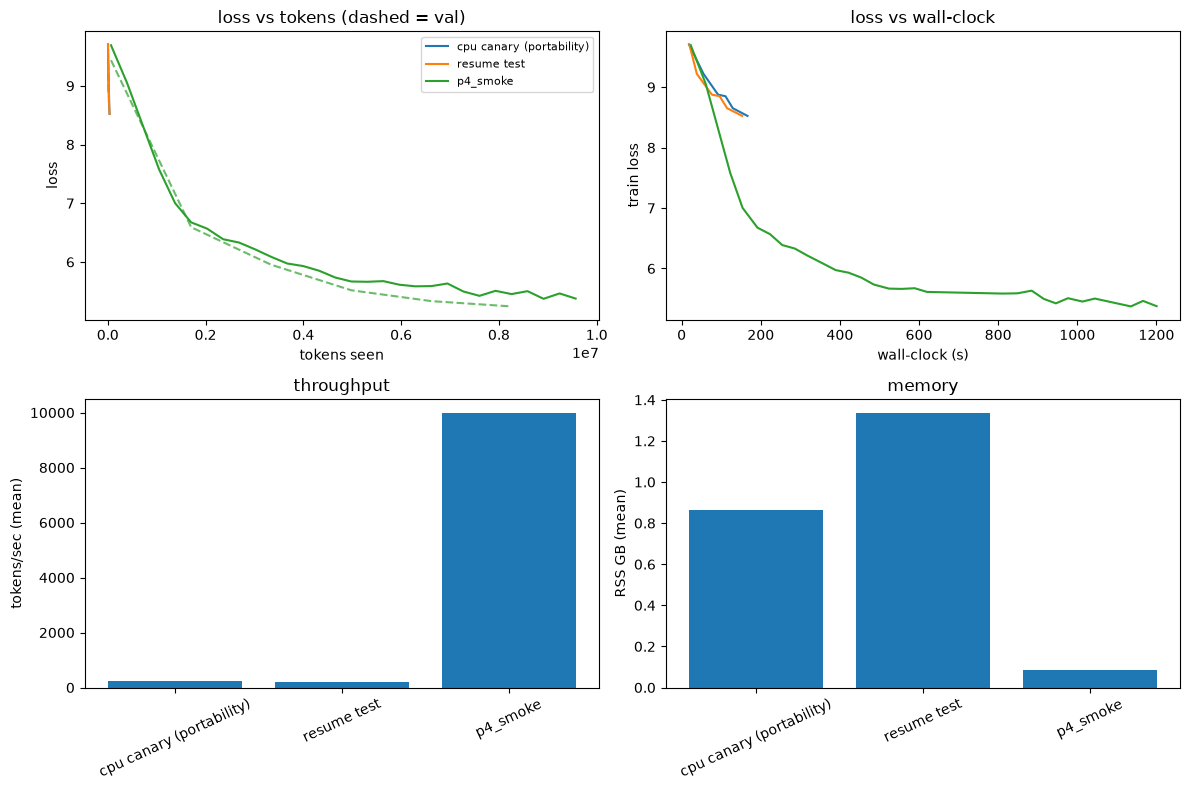

In [4]:
plot_runs(
    ["20260711_p4_cpu-canary", "20260711_p4_resume-test", "20260711_p4_s-smoke"],
    labels={
        "20260711_p4_cpu-canary": "cpu canary (portability)",
        "20260711_p4_resume-test": "resume test",
        "20260711_p4_s-smoke": "p4_smoke",
    },
);

## 4. lr sweep + baseline (overnight pipeline)

Three short (300-step) runs at lr $\times$0.3 / $\times$1 / $\times$3 around the D-021 default
(1e-3), then the full 1500-step baseline at whichever lr won by lowest val_loss. Skips
gracefully (see `plot_runs`'s docstring) if the pipeline hasn't reached these runs yet.

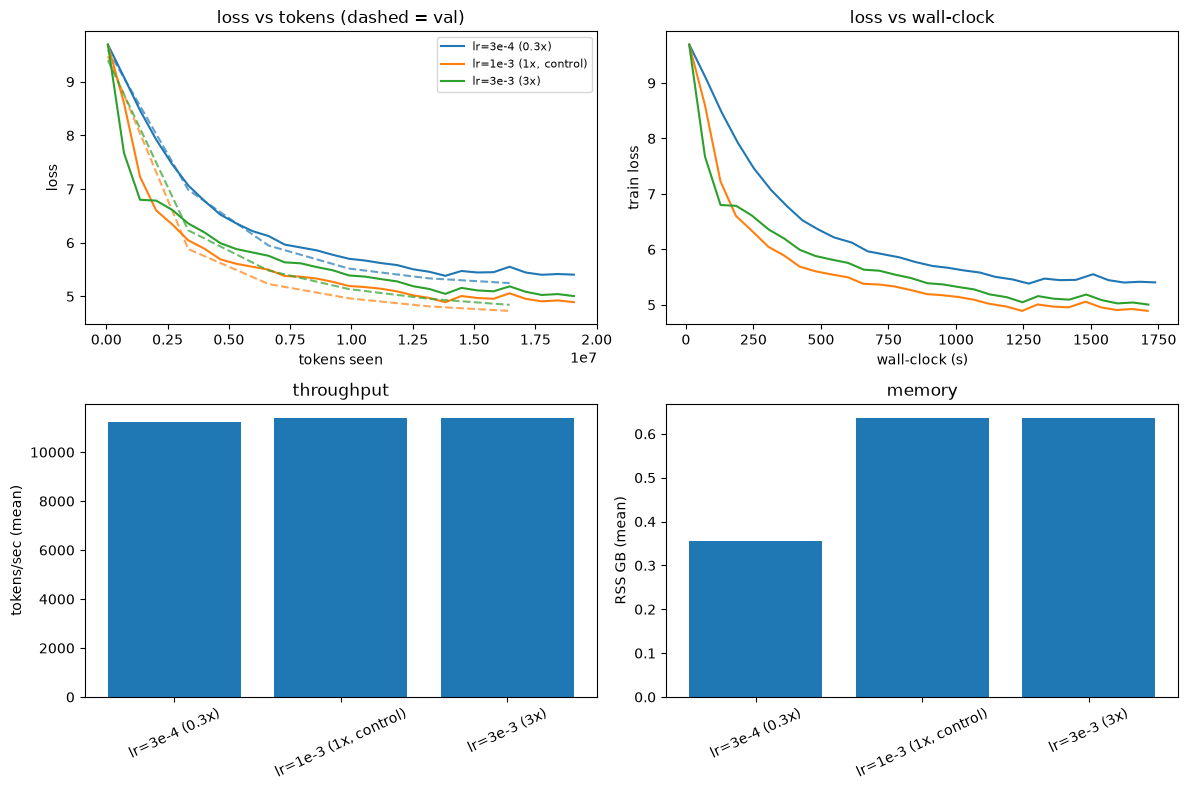

In [5]:
plot_runs(
    ["20260711_p4_s-lr-sweep-lo", "20260711_p4_s-lr-sweep-mid", "20260711_p4_s-lr-sweep-hi"],
    labels={
        "20260711_p4_s-lr-sweep-lo": "lr=3e-4 (0.3x)",
        "20260711_p4_s-lr-sweep-mid": "lr=1e-3 (1x, control)",
        "20260711_p4_s-lr-sweep-hi": "lr=3e-3 (3x)",
    },
);

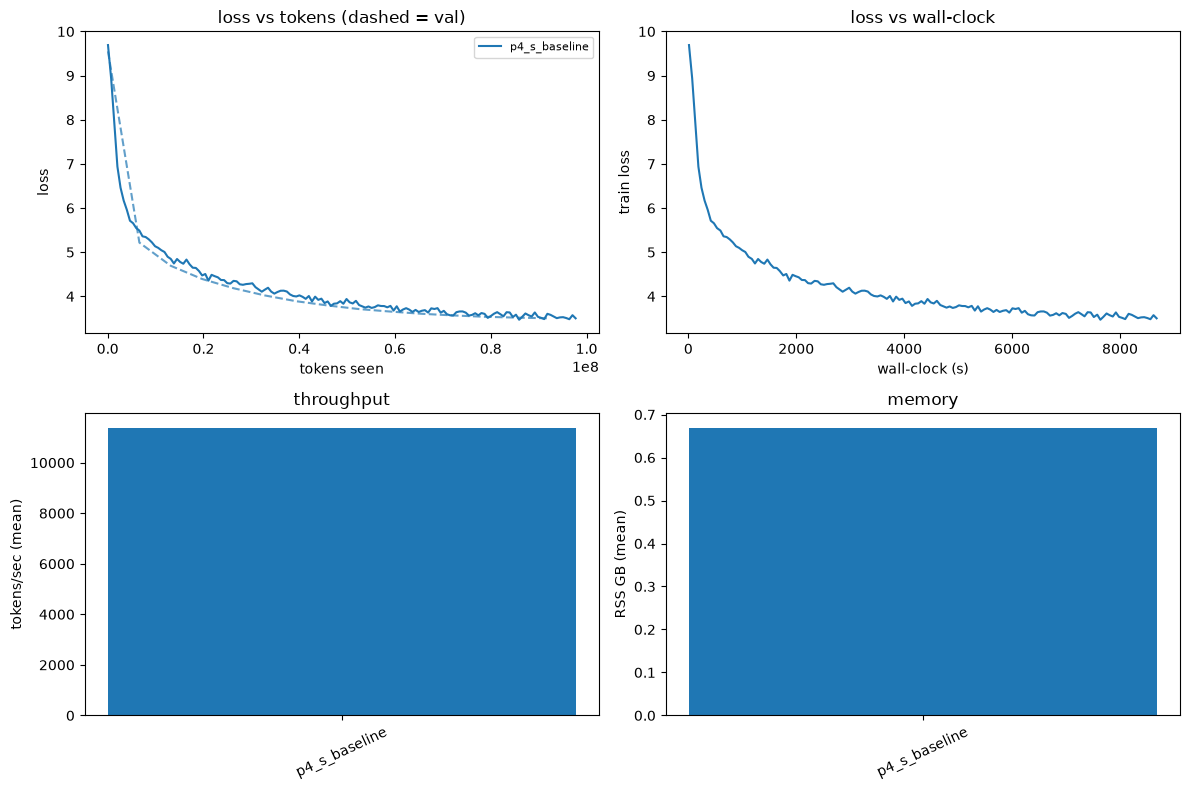

In [6]:
for candidate in ["20260711_p4_s-baseline", "20260711_p4_s-baseline-auto"]:
    if (EXPERIMENTS_DIR / candidate / "metrics.jsonl").exists():
        plot_runs([candidate], labels={candidate: "p4_s_baseline"})
        break
else:
    print("baseline run not finished yet -- re-run this cell later")

## 5. Reading a loss curve (teaching section)

Grounded in `p4_smoke`'s actual numbers (S-tier, 9.71M params, vocab 16,000):

- **Random-init baseline:** step 0 train_loss = 9.692, essentially $\ln(16000) = 9.68$ -- the
  loss a model predicting the uniform distribution over the vocabulary would get. This confirms
  D-016's init choice: logits start near-uniform regardless of `d_model`, so training begins
  from "knows nothing" rather than some accidental head start or handicap.
- **The initial cliff:** loss drops fastest in the first handful of steps (learning unigram/
  bigram statistics and basic syntax is "cheap" -- the model doesn't need any real understanding
  to beat uniform-random by a lot). `grad_norm` mirrors this: it starts largest (5.3 at step 0,
  up to ~7 in the CPU canary) and falls fast as the model finds a reasonable loss basin --
  early on, the model is farthest from any good solution, so the raw gradient is biggest;
  `grad_clip=1.0` is what keeps that initial spike from taking a destructively large step.
- **The power-law region:** after the cliff, loss keeps falling but much more slowly and
  smoothly (5.37 by step 145 vs. 9.69 at step 0, most of that drop happening in the first ~30
  steps) -- this is the regime scaling laws (Kaplan et al. '20, Chinchilla) describe as a power
  law in tokens/compute; each further loss decrement needs more data/compute than the last.
- **Warmup, visible in `lr` not `loss`:** `lr` ramps linearly for `warmup_steps`, then cosines
  down. Warmup exists because early gradients (per the cliff, above) are large and the
  optimizer's Adam moment estimates haven't stabilized yet -- taking full-size steps into that
  regime is a common cause of early divergence, which is exactly what `p4_s_lr_sweep`'s
  lr-hi run (section 4) is designed to let you watch happen.
- **Spikes:** a sudden jump in `train_loss` or `grad_norm` mid-training (not seen in this short
  smoke run) usually means the optimizer took a step into a much worse region -- often from a
  batch of unusual data, an lr that's locally too high for the current curvature, or (at bigger
  scale) numerical issues in mixed precision. `grad_clip` limits the damage of any single step;
  it doesn't prevent the spike itself.
- **Perplexity = $e^{\text{loss}}$:** `registry.csv`'s `final_ppl` column is `exp(val_loss)` --
  intuitively "the model is as uncertain as if choosing uniformly among this many tokens."
  Comparing ppl across *different tokenizers* is invalid: a coarser/finer vocabulary changes
  how many tokens a sequence takes and thus what loss-per-token even means -- comparisons must
  hold the tokenizer fixed (which every run in this registry does: hf_bpe_16k, D-014).

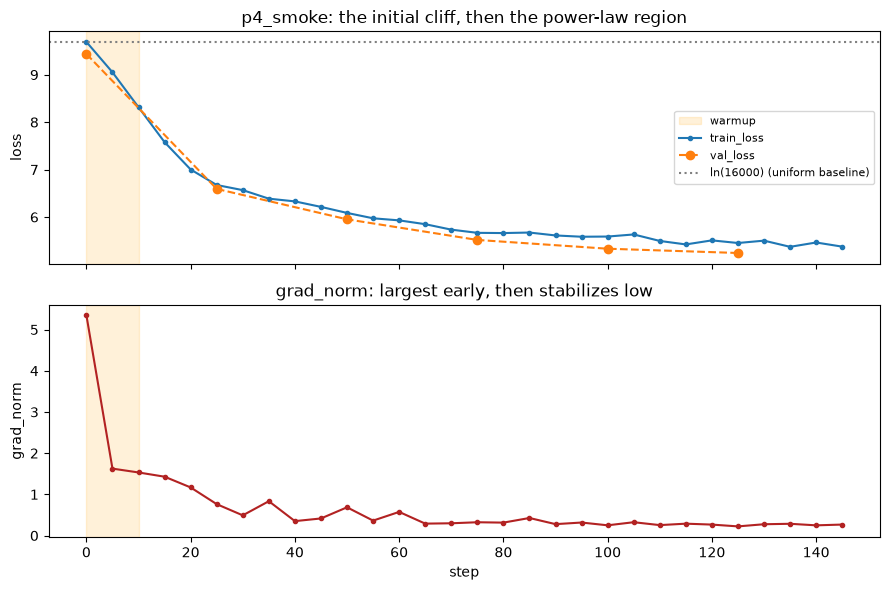

In [7]:
df = load_metrics("20260711_p4_s-smoke")
fig, (ax_loss, ax_grad) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

warmup_steps = 10  # configs/train_s_smoke.yaml
ax_loss.axvspan(0, warmup_steps, color="orange", alpha=0.15, label="warmup")
ax_loss.plot(df["step"], df["train_loss"], marker=".", label="train_loss")
val_df = df.dropna(subset=["val_loss"]) if "val_loss" in df.columns else df.iloc[0:0]
ax_loss.plot(val_df["step"], val_df["val_loss"], "--", marker="o", label="val_loss")
ax_loss.axhline(9.68, color="gray", linestyle=":", label=r"$\ln(16000)$ (uniform baseline)")
ax_loss.set(ylabel="loss", title="p4_smoke: the initial cliff, then the power-law region")
ax_loss.legend(fontsize=8)

ax_grad.plot(df["step"], df["grad_norm"], marker=".", color="firebrick")
ax_grad.axvspan(0, warmup_steps, color="orange", alpha=0.15)
ax_grad.set(xlabel="step", ylabel="grad_norm", title="grad_norm: largest early, then stabilizes low")

fig.tight_layout()